In [2]:
import pandas as pd
import numpy as np
import pandas as pd

main_data = pd.read_csv(
    '/home/bibek/Desktop/pandas_practice_realDataset/datasets/sampleSuperstore.csv',
    encoding='latin1'
)

main_data.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
main_data.shape

(9994, 21)

In [4]:
main_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
main_data.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:
main_data.isna().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [7]:
main_data.duplicated().sum()

np.int64(0)

In [8]:
main_data['Order Date']=pd.to_datetime(main_data['Order Date'],errors='coerce')
main_data['Order Date'].dtype

dtype('<M8[ns]')

In [9]:
main_data['Year']=main_data['Order Date'].dt.year
main_data['Year']

0       2016
1       2016
2       2016
3       2015
4       2015
        ... 
9989    2014
9990    2017
9991    2017
9992    2017
9993    2017
Name: Year, Length: 9994, dtype: int32

In [10]:
main_data['Month']=main_data['Order Date'].dt.month_name()
main_data['Month']

0       November
1       November
2           June
3        October
4        October
          ...   
9989     January
9990    February
9991    February
9992    February
9993         May
Name: Month, Length: 9994, dtype: object

In [11]:
main_data['Quarter']=main_data['Order Date'].dt.quarter
main_data['Quarter']

0       4
1       4
2       2
3       4
4       4
       ..
9989    1
9990    1
9991    1
9992    1
9993    2
Name: Quarter, Length: 9994, dtype: int32

In [12]:
main_data[['Order Date','Year','Month','Quarter']].head()

,Order Date,Year,Month,Quarter
0,2016-11-08,2016,November,4
1,2016-11-08,2016,November,4
2,2016-06-12,2016,June,2
3,2015-10-11,2015,October,4
4,2015-10-11,2015,October,4


In [13]:
main_data.shape

(9994, 24)

In [14]:
main_data['Sales'].sum()

np.float64(2297200.8603)

In [15]:
main_data['Profit'].sum()

np.float64(286397.0217)

In [16]:
highest_selling_category=main_data.groupby('Category')['Profit'].sum().sort_values(ascending=False).index[0]
highest_selling_category

'Technology'

In [17]:
most_profitable_state=main_data.groupby('State')['Profit'].sum().sort_values(ascending=False).index[0]
most_profitable_state

'California'

In [18]:
customers_by_sales=main_data.groupby(['Customer ID','Customer Name'])['Sales'].sum().sort_values(ascending=False).head(10)
customers_by_sales

Customer ID  Customer Name     
SM-20320     Sean Miller           25043.050
TC-20980     Tamara Chand          19052.218
RB-19360     Raymond Buch          15117.339
TA-21385     Tom Ashbrook          14595.620
AB-10105     Adrian Barton         14473.571
KL-16645     Ken Lonsdale          14175.229
SC-20095     Sanjit Chand          14142.334
HL-15040     Hunter Lopez          12873.298
SE-20110     Sanjit Engle          12209.438
CC-12370     Christopher Conant    12129.072
Name: Sales, dtype: float64

In [19]:
customers_by_profit=main_data.groupby(['Customer ID','Customer Name'])['Profit'].sum().sort_values(ascending=False).head(10)
customers_by_profit

Customer ID  Customer Name       
TC-20980     Tamara Chand            8981.3239
RB-19360     Raymond Buch            6976.0959
SC-20095     Sanjit Chand            5757.4119
HL-15040     Hunter Lopez            5622.4292
AB-10105     Adrian Barton           5444.8055
TA-21385     Tom Ashbrook            4703.7883
CM-12385     Christopher Martinez    3899.8904
KD-16495     Keith Dawkins           3038.6254
AR-10540     Andy Reiter             2884.6208
DR-12940     Daniel Raglin           2869.0760
Name: Profit, dtype: float64

In [20]:
main_data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Quarter
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,November,4
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,November,4
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,June,2
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,October,4
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,October,4


In [31]:
sales_under_order=main_data.groupby('Order ID')['Sales'].sum()
sales_under_order
average_order_value=sales_under_order.mean()
average_order_value

np.float64(458.61466566180883)

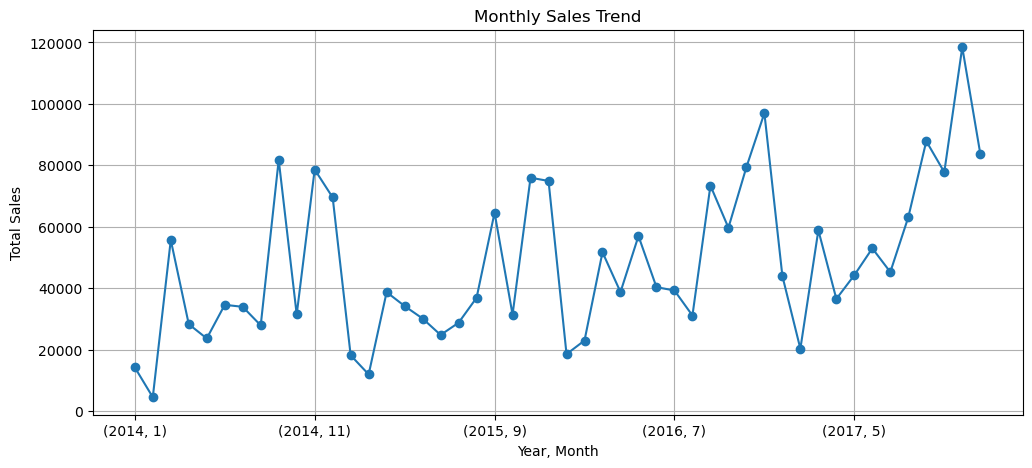

In [42]:
import matplotlib.pyplot as plt

monthly_sales = (
    main_data
    .groupby(['Year', 'Month'])['Sales']
    .sum()
)

monthly_sales.plot(
    kind='line',
    figsize=(12, 5),
    marker='o'
)

plt.xlabel("Year, Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend")
plt.grid(True)

plt.show()